## Tax counterfactual: 20% higher new-car prices

Three scenarios at the same heterogeneous primitive: `pnew[j] = pnew_base + pnew_slope*j`, `u_0[tau,j] = xi_0 + eta*j`, `u_a[tau,j] = -gam` (constant).

1. **Baseline** equilibrium.
2. **New-car prices +20%, used-car prices held at baseline equilibrium.** No Newton solve.
3. **New-car prices +20%, used-car prices re-solved.** Full re-equilibration.

Aggregates: new-car demand, no-car share, average owned-car age, mean used-car price. Plus a heatmap of % changes in equilibrium used-car prices (3 vs 1).

Build the binary once (from the parent `fut2/` folder):
```
make run_equilibrium_counterfactual-m.exe
```
Each scenario's raw Futhark output is cached to `<scenario>.npz` in this folder. Delete the `.npz` files (or run the *Clear cache* cell at the bottom) whenever you change parameters.

In [30]:
import ast
import re
import shutil
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE  = Path('.').resolve()
BIN   = HERE.parent / 'run_equilibrium_counterfactual-m.exe'
CACHE = HERE
assert BIN.exists(), f'{BIN} not found - run `make run_equilibrium_counterfactual-m.exe` in {HERE.parent}'

# The binary is a Linux ELF compiled inside WSL. On Windows-side Python,
# invoke it through wsl.exe; on Linux/WSL-side Python, call it directly.
_ON_WINDOWS = sys.platform.startswith('win')
if _ON_WINDOWS:
    _WSL = shutil.which('wsl')
    assert _WSL, 'wsl.exe not found on PATH'
    def _to_wsl_path(p: Path) -> str:
        s = str(p.resolve())
        drive, rest = s[0].lower(), s[2:].replace('\\', '/')
        return f'/mnt/{drive}{rest}'
    _BIN_CMD = [_WSL, _to_wsl_path(BIN)]
else:
    _BIN_CMD = [str(BIN)]

_SUFFIX_RE = re.compile(r'([fui]\d+)\b')

def _parse_value(s):
    s = _SUFFIX_RE.sub('', s)
    s = re.sub(r'\btrue\b', 'True', s)
    s = re.sub(r'\bfalse\b', 'False', s)
    s = re.sub(r'\bnan\b', "float('nan')", s)
    return ast.literal_eval(s)

def _split_top_level(s):
    i, n = 0, len(s)
    while i < n:
        while i < n and s[i].isspace():
            i += 1
        if i >= n:
            break
        if s[i] == '[':
            depth, j = 1, i + 1
            while j < n and depth:
                if s[j] == '[': depth += 1
                elif s[j] == ']': depth -= 1
                j += 1
            yield s[i:j]; i = j
        else:
            j = i
            while j < n and not s[j].isspace():
                j += 1
            yield s[i:j]; i = j

def _fmt(x):
    if isinstance(x, bool):
        return 'true' if x else 'false'
    if isinstance(x, (int, np.integer)):
        return f'{int(x)}i64'
    if isinstance(x, (float, np.floating)):
        return f'{repr(float(x))}f64'
    if isinstance(x, np.ndarray):
        if x.ndim == 0:
            return _fmt(x.item())
        return '[' + ','.join(_fmt(sub) for sub in x) + ']'
    raise TypeError(f'unsupported arg type: {type(x)}')

def run_entry(entry, *args):
    payload = ' '.join(_fmt(a) for a in args)
    proc = subprocess.run(_BIN_CMD + ['-e', entry],
                          input=payload.encode(),
                          capture_output=True, check=True)
    return [_parse_value(v) for v in _split_top_level(proc.stdout.decode())]

def _fmt_param(v):
    """Compact, filename-safe rendering of a parameter value."""
    if isinstance(v, (float, np.floating)):
        return f'{float(v):g}'
    return str(v)

def _cache_path(scenario, params):
    parts = [scenario] + [f'{k}{_fmt_param(v)}' for k, v in params.items()]
    return CACHE / ('-'.join(parts) + '.npz')

def cached(scenario, params, compute):
    """Return contents of <scenario>-<params>.npz; if missing, call compute() to
    produce a dict-of-arrays, persist it, and return it.
    """
    path = _cache_path(scenario, params)
    if path.exists():
        with np.load(path, allow_pickle=False) as f:
            data = {k: f[k] for k in f.files}
        print(f'  loaded {path.name}')
        return data
    print(f'  computing {path.name} ...')
    data = compute()
    np.savez(path, **data)
    return data

In [31]:
# Shape
n        = 2
c        = 20
Ax       = 25
sa_max   = 20

# Newton
transcost = 0.0
acc0      = -5.0
damp      = 0.5
tol       = 1e-6
max_iter  = 50

# Heterogeneous primitives
mum        = np.array([0.1, 0.3])
xi_0       = 6.0
eta        = 0.025
gam        = 0.5
pnew_base  = 200.0
pnew_slope = 10.0

# Counterfactual
tax_rate   = 0.20

pnew_baseline = pnew_base + pnew_slope * np.arange(c)
pnew_taxed    = (1 + tax_rate) * pnew_baseline

# Cache-filename params (drives <scenario>-<params>.npz naming).
# Newton internals (damp, tol, max_iter, sa_max, transcost, acc0) and `mum` are
# excluded - tweak them without invalidating caches; if you do want them, add
# them here.
_base_params = dict(n=n, c=c, Ax=Ax,
                    xi=xi_0, eta=eta, gam=gam,
                    pb=pnew_base, ps=pnew_slope)
_tax_params  = dict(**_base_params, tr=tax_rate)

In [32]:
def aggregate(p, q_taus, ccps, tw, c, Ax):
    """Return (new_car_demand[c], no_car_share, avg_owned_age, mean_used_price).

    Index conventions match run_equilibrium_counterfactual.fut:
      state s < ns-1 = Car{j = s//Ax, age = (s%Ax) + 1};  state ns-1 = NoCar.
      decision 1 + j*Ax = Trade{cartype=j, age=0} (buy new car j).
    """
    total_tw = tw.sum()
    dec_idx  = 1 + np.arange(c) * Ax
    ccp_new  = ccps[:, :, dec_idx]                                  # [n, ns, c]
    new_per_tau = (q_taus[:, :, None] * ccp_new).sum(axis=1)        # [n, c]
    new_car_demand = (tw[:, None] * new_per_tau).sum(axis=0) / total_tw  # [c]

    no_car_share = (tw * q_taus[:, -1]).sum() / total_tw

    ns      = q_taus.shape[1]
    ages    = (np.arange(ns - 1) % Ax) + 1
    q_owned = q_taus[:, :-1]
    avg_owned_age = ((tw[:, None] * q_owned * ages).sum()
                     / (tw[:, None] * q_owned).sum())

    mean_used_price = p[:, 1:].mean()
    return new_car_demand, no_car_share, avg_owned_age, mean_used_price

In [33]:
# 1. Baseline equilibrium
def _run_baseline():
    p, q, ccp, tw, it, conv = run_entry(
        'solve_eqb_het',
        n, c, Ax, sa_max,
        transcost, acc0, damp, tol, max_iter,
        mum, xi_0, eta, gam, pnew_base, pnew_slope,
    )
    assert conv, f'baseline did not converge in {it} iterations'
    return {'p': np.asarray(p), 'q_taus': np.asarray(q), 'ccp': np.asarray(ccp),
            'tw': np.asarray(tw), 'iter': np.int64(it), 'conv': np.bool_(conv)}

base = cached('baseline', _base_params, _run_baseline)
p_base, q_base, ccp_base, tw = base['p'], base['q_taus'], base['ccp'], base['tw']
ncd_b, ncs_b, age_b, mup_b = aggregate(p_base, q_base, ccp_base, tw, c, Ax)

  loaded baseline-n2-c20-Ax25-xi6-eta0.025-gam0.5-pb200-ps10.npz


In [34]:
# 2. New-car prices +20%, used-car prices held at baseline.
p_fixed_used = p_base.copy()
p_fixed_used[:, 0] = pnew_taxed

def _run_fixed_used():
    q, ccp, tw_f = run_entry(
        'eval_at_p',
        n, c, Ax, sa_max,
        transcost, acc0,
        mum, xi_0, eta, gam,
        pnew_taxed, p_fixed_used,
    )
    return {'p': p_fixed_used, 'q_taus': np.asarray(q), 'ccp': np.asarray(ccp),
            'tw': np.asarray(tw_f)}

fix = cached('fixed_used', _tax_params, _run_fixed_used)
ncd_f, ncs_f, age_f, mup_f = aggregate(fix['p'], fix['q_taus'], fix['ccp'], fix['tw'], c, Ax)

  loaded fixed_used-n2-c20-Ax25-xi6-eta0.025-gam0.5-pb200-ps10-tr0.2.npz


In [35]:
# 3. New-car prices +20%, used-car prices re-solved.
def _run_taxed():
    p, q, ccp, tw_t, it, conv = run_entry(
        'solve_eqb_het',
        n, c, Ax, sa_max,
        transcost, acc0, damp, tol, max_iter,
        mum, xi_0, eta, gam,
        (1 + tax_rate) * pnew_base,
        (1 + tax_rate) * pnew_slope,
    )
    assert conv, f'taxed did not converge in {it} iterations'
    return {'p': np.asarray(p), 'q_taus': np.asarray(q), 'ccp': np.asarray(ccp),
            'tw': np.asarray(tw_t), 'iter': np.int64(it), 'conv': np.bool_(conv)}

tax = cached('taxed', _tax_params, _run_taxed)
p_tax = tax['p']
ncd_t, ncs_t, age_t, mup_t = aggregate(p_tax, tax['q_taus'], tax['ccp'], tax['tw'], c, Ax)

  loaded taxed-n2-c20-Ax25-xi6-eta0.025-gam0.5-pb200-ps10-tr0.2.npz


In [36]:
table = pd.DataFrame(
    {
        'New-car demand':        [ncd_b.sum(),  ncd_f.sum(),  ncd_t.sum()],
        'No-car share':          [ncs_b,        ncs_f,        ncs_t],
        'Avg owned-car age':     [age_b,        age_f,        age_t],
        'Mean used-car price':   [mup_b,        mup_f,        mup_t],
    },
    index=['Baseline', '+20% new, used fixed', '+20% new, used re-solved'],
)
table.style.format('{:.4f}')

,New-car demand,No-car share,Avg owned-car age,Mean used-car price
Baseline,0.0566,0.0203,9.7860,63.0714
"+20% new, used fixed",0.0005,0.0204,10.0975,63.0714
"+20% new, used re-solved",0.0514,0.0418,10.4705,82.8863


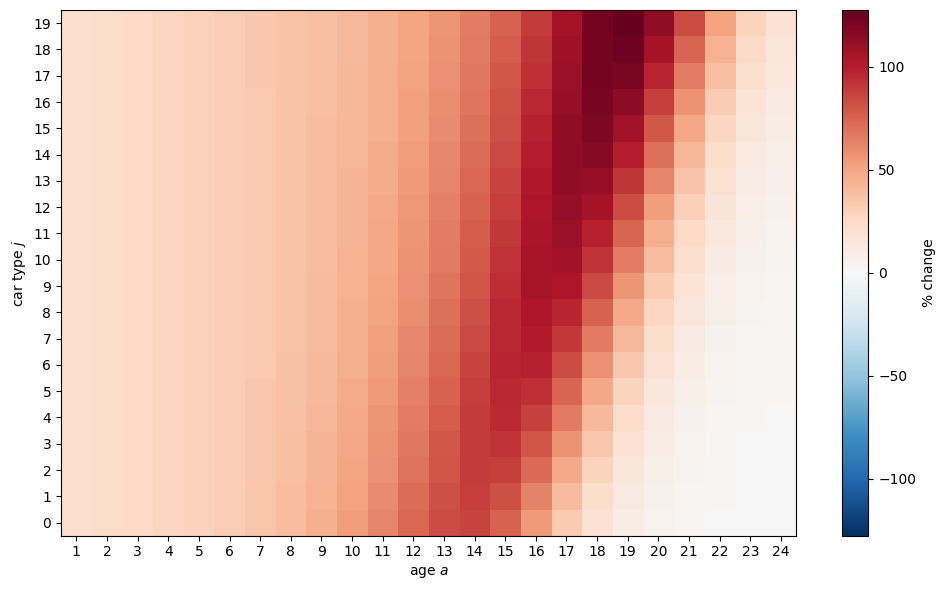

In [ ]:
# % change in equilibrium used-car prices: scenario 3 vs scenario 1
pct = (p_tax[:, 1:] - p_base[:, 1:]) / p_base[:, 1:] * 100
vmax = np.abs(pct).max()

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pct, aspect='auto', cmap='RdBu_r', origin='lower',
               vmin=-vmax, vmax=vmax)
ax.set_xlabel('age $a$')
ax.set_ylabel('car type $j$')
ax.set_xticks(np.arange(Ax - 1))
ax.set_xticklabels(np.arange(1, Ax))
ax.set_yticks(np.arange(c))
fig.colorbar(im, ax=ax, label='% change')
fig.tight_layout()
plt.show()

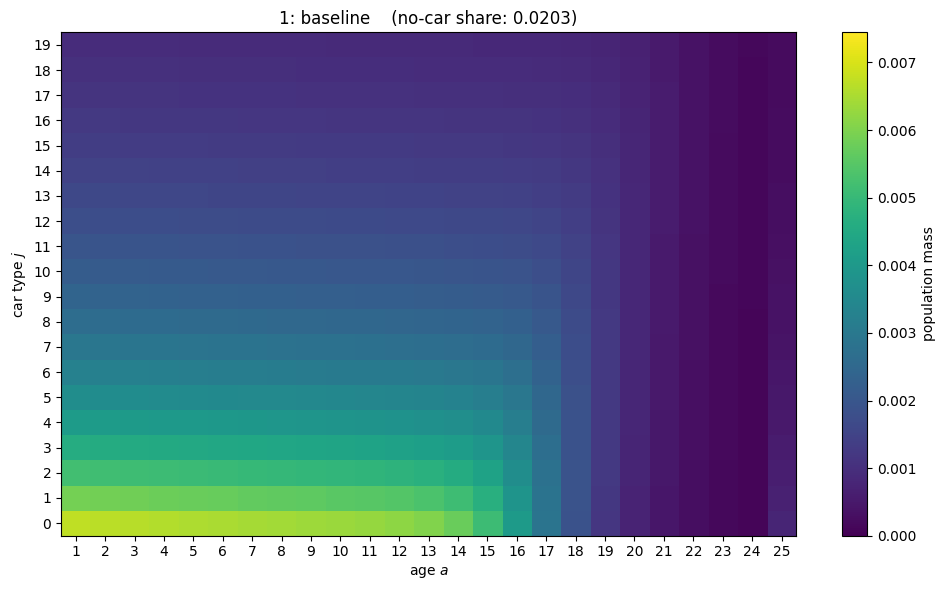

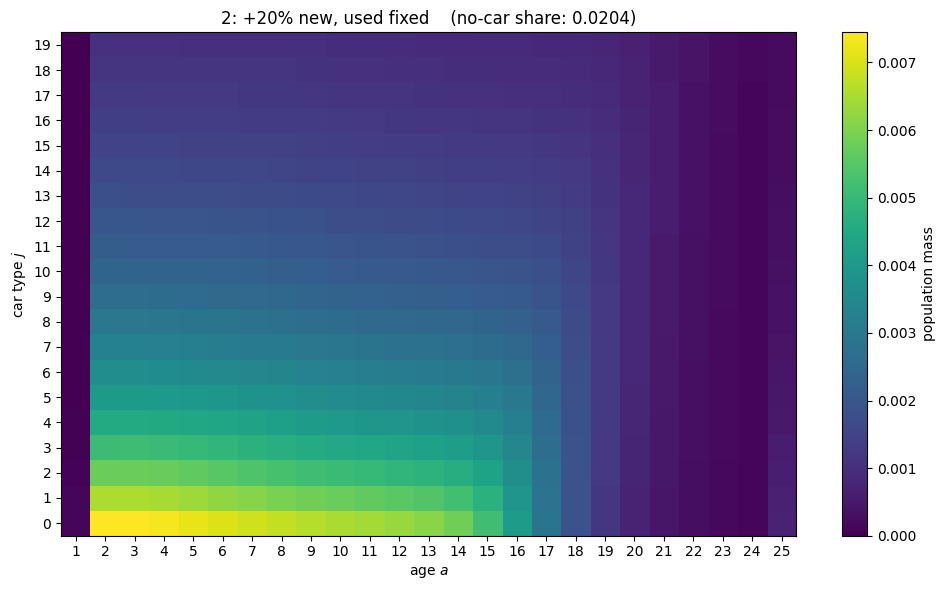

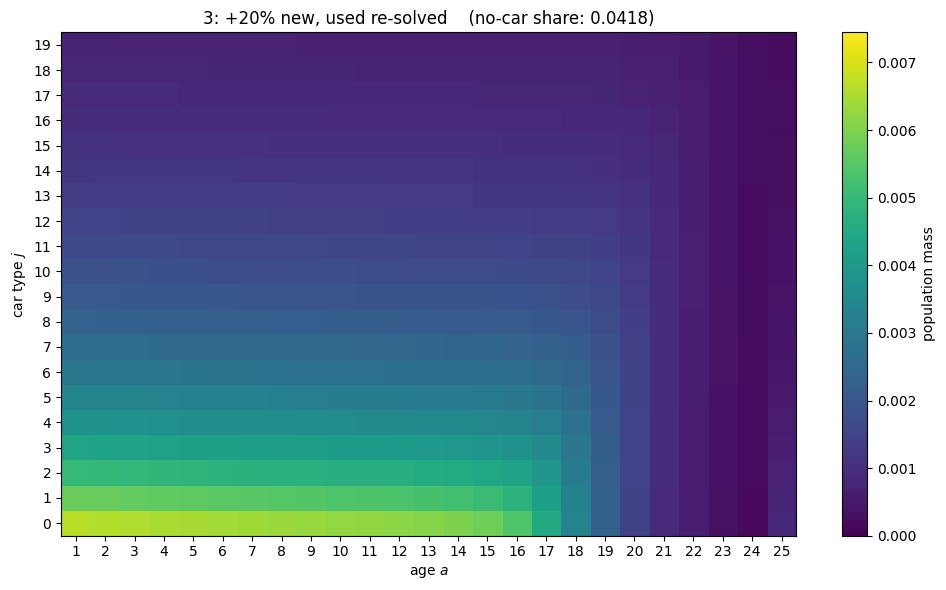

In [38]:
# Population-weighted state mass over car states (NoCar is excluded; that
# share is in the table). Car state s = j*Ax + (a-1), j in [0,c), a in [1,Ax].
def state_mass(q_taus, tw, c, Ax):
    ns = q_taus.shape[1]
    pop = (tw[:, None] * q_taus[:, :ns - 1]).sum(axis=0) / tw.sum()
    return pop.reshape(c, Ax)

sm_base = state_mass(q_base,       tw,         c, Ax)
sm_fix  = state_mass(fix['q_taus'], fix['tw'], c, Ax)
sm_tax  = state_mass(tax['q_taus'], tax['tw'], c, Ax)

vmax_q = max(sm_base.max(), sm_fix.max(), sm_tax.max())

def _plot_q(sm, title, no_car):
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(sm, aspect='auto', cmap='viridis', origin='lower',
                   vmin=0, vmax=vmax_q)
    ax.set_xlabel('age $a$')
    ax.set_ylabel('car type $j$')
    ax.set_xticks(np.arange(Ax))
    ax.set_xticklabels(np.arange(1, Ax + 1))
    ax.set_yticks(np.arange(c))
    ax.set_title(f'{title}    (no-car share: {no_car:.4f})')
    fig.colorbar(im, ax=ax, label='population mass')
    fig.tight_layout()
    plt.show()

_plot_q(sm_base, '1: baseline',              ncs_b)
_plot_q(sm_fix,  '2: +20% new, used fixed',  ncs_f)
_plot_q(sm_tax,  '3: +20% new, used re-solved', ncs_t)

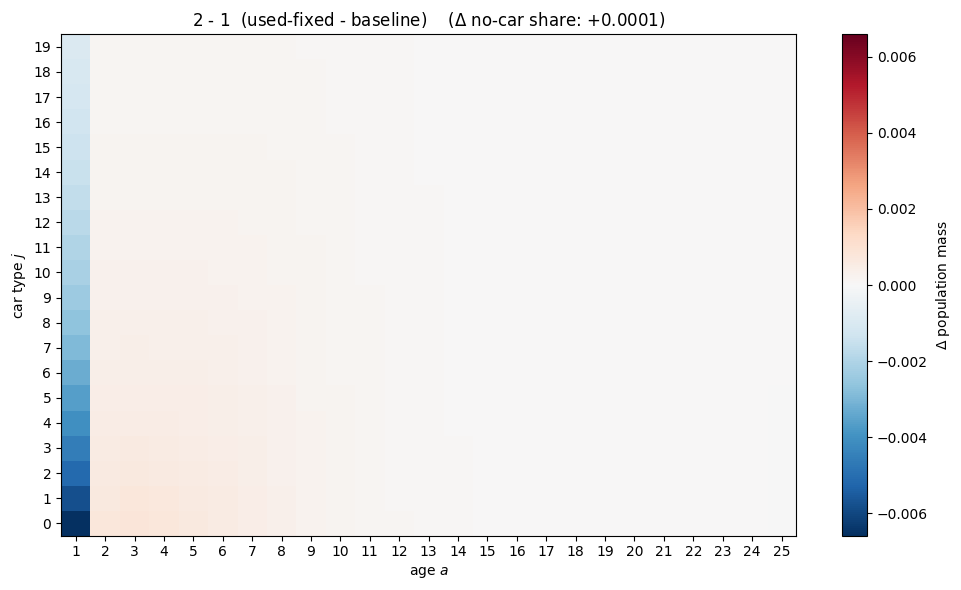

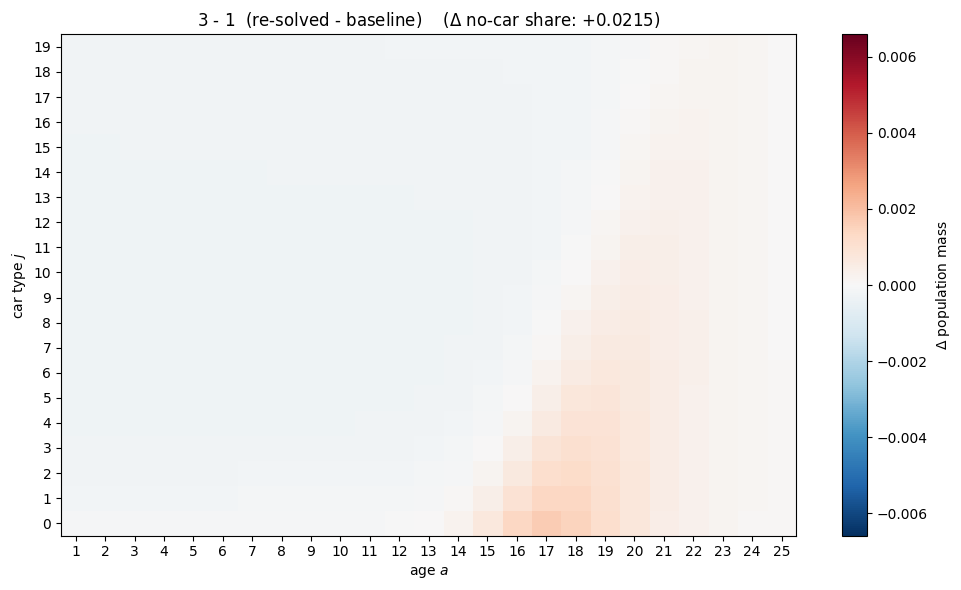

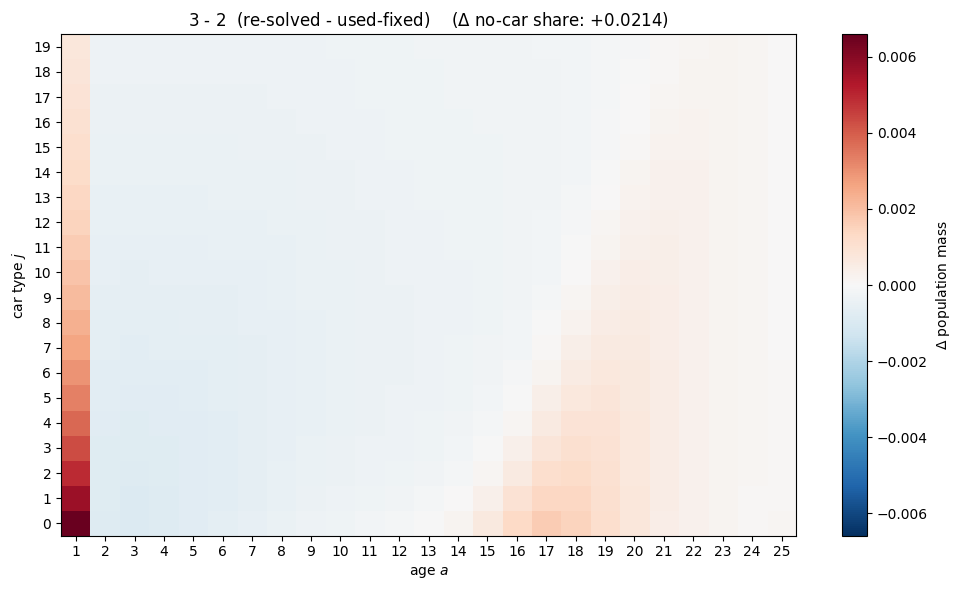

In [39]:
# Pairwise state-mass differences, "later minus earlier" convention.
# (3 - 1) decomposes as (3 - 2) + (2 - 1): direct effect on choices at fixed
# used prices, plus the re-equilibration effect.
delta_21 = sm_fix - sm_base
delta_31 = sm_tax - sm_base
delta_32 = sm_tax - sm_fix
vmax_d   = max(np.abs(delta_21).max(),
               np.abs(delta_31).max(),
               np.abs(delta_32).max())

def _plot_delta(delta, title, no_car_diff):
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(delta, aspect='auto', cmap='RdBu_r', origin='lower',
                   vmin=-vmax_d, vmax=vmax_d)
    ax.set_xlabel('age $a$')
    ax.set_ylabel('car type $j$')
    ax.set_xticks(np.arange(Ax))
    ax.set_xticklabels(np.arange(1, Ax + 1))
    ax.set_yticks(np.arange(c))
    ax.set_title(f'{title}    ($\\Delta$ no-car share: {no_car_diff:+.4f})')
    fig.colorbar(im, ax=ax, label=r'$\Delta$ population mass')
    fig.tight_layout()
    plt.show()

_plot_delta(delta_21, '2 - 1  (used-fixed - baseline)',       ncs_f - ncs_b)
_plot_delta(delta_31, '3 - 1  (re-solved - baseline)',        ncs_t - ncs_b)
_plot_delta(delta_32, '3 - 2  (re-solved - used-fixed)',      ncs_t - ncs_f)

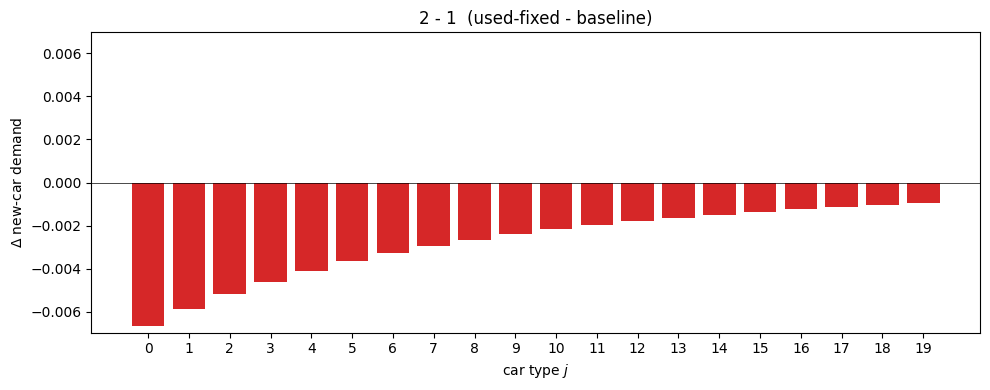

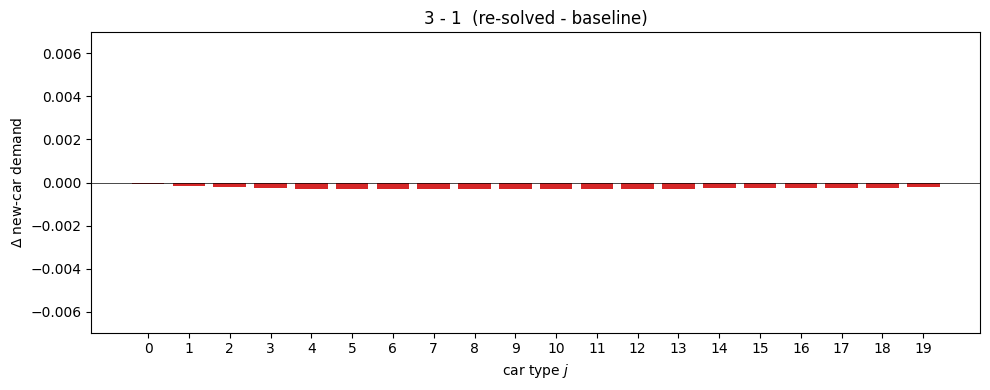

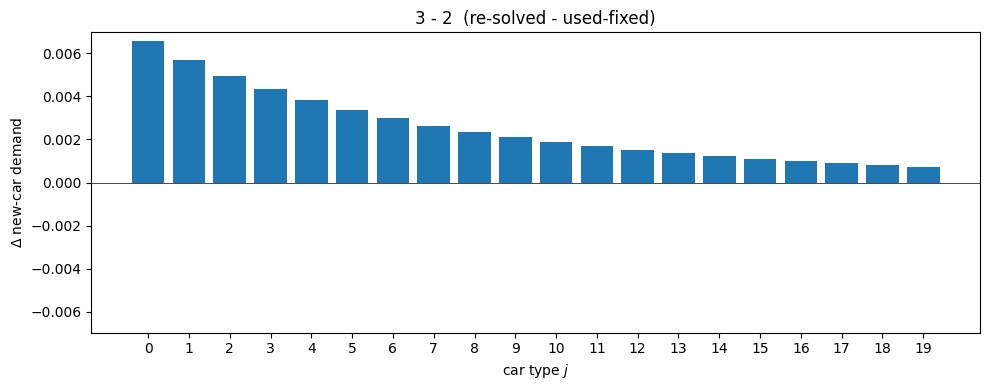

In [40]:
# Change in new-car demand by car type, one figure per pairwise difference.
delta_ncd_21 = ncd_f - ncd_b
delta_ncd_31 = ncd_t - ncd_b
delta_ncd_32 = ncd_t - ncd_f
ylim_ncd = max(np.abs(delta_ncd_21).max(),
               np.abs(delta_ncd_31).max(),
               np.abs(delta_ncd_32).max())

def _plot_ncd_delta(delta, title):
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['tab:blue' if d >= 0 else 'tab:red' for d in delta]
    ax.bar(np.arange(c), delta, color=colors)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_xlabel('car type $j$')
    ax.set_ylabel(r'$\Delta$ new-car demand')
    ax.set_xticks(np.arange(c))
    ax.set_ylim(-ylim_ncd * 1.05, ylim_ncd * 1.05)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()

_plot_ncd_delta(delta_ncd_21, '2 - 1  (used-fixed - baseline)')
_plot_ncd_delta(delta_ncd_31, '3 - 1  (re-solved - baseline)')
_plot_ncd_delta(delta_ncd_32, '3 - 2  (re-solved - used-fixed)')

In [41]:
# Remove ALL cached Futhark outputs in this folder (every parameter variant).
# To remove only the current parameter set, use cached(...)`s exact filename.
for scenario in ('baseline', 'fixed_used', 'taxed'):
    for p in CACHE.glob(f'{scenario}-*.npz'):
        p.unlink()
        print(f'removed {p.name}')

removed baseline-n2-c20-Ax25-xi6-eta0.025-gam0.5-pb200-ps10.npz
removed fixed_used-n2-c20-Ax25-xi6-eta0.025-gam0.5-pb200-ps10-tr0.2.npz
removed taxed-n2-c20-Ax25-xi6-eta0.025-gam0.5-pb200-ps10-tr0.2.npz
